In [ ]:
! pip install --upgrade pip        # Requires the latest pip
! pip install tensorflow           # Current stable release for CPU and GPU

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import statsmodels as sm
import statsmodels.api as smt

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential


# 1. Data Processing

In [ ]:
cpi_train_raw = pd.read_csv('CPI_train.csv')
cpi_train_raw['Quarter']=pd.to_datetime(cpi_train_raw['Quarter'],  format='%Y-%m')
cpi_train_raw.set_index('Quarter', inplace=True)
cpi_train_raw.head()

,CPI
Quarter,
1990-03-01,50.3
1990-06-01,51.7
1990-09-01,51.3
1990-12-01,51.8
1991-03-01,52.9


In [ ]:
cpi_train = cpi_train_raw.dropna()               # Drop all Nans
cpi_train = cpi_train.values          # Convert from DataFrame to Python Array
cpi_train = cpi_train.astype('float') # You need to make sure the data is type of float

# 2. Exploratory Data Analysis (EDA)

## 2.1 CPI Trend and Seasonality

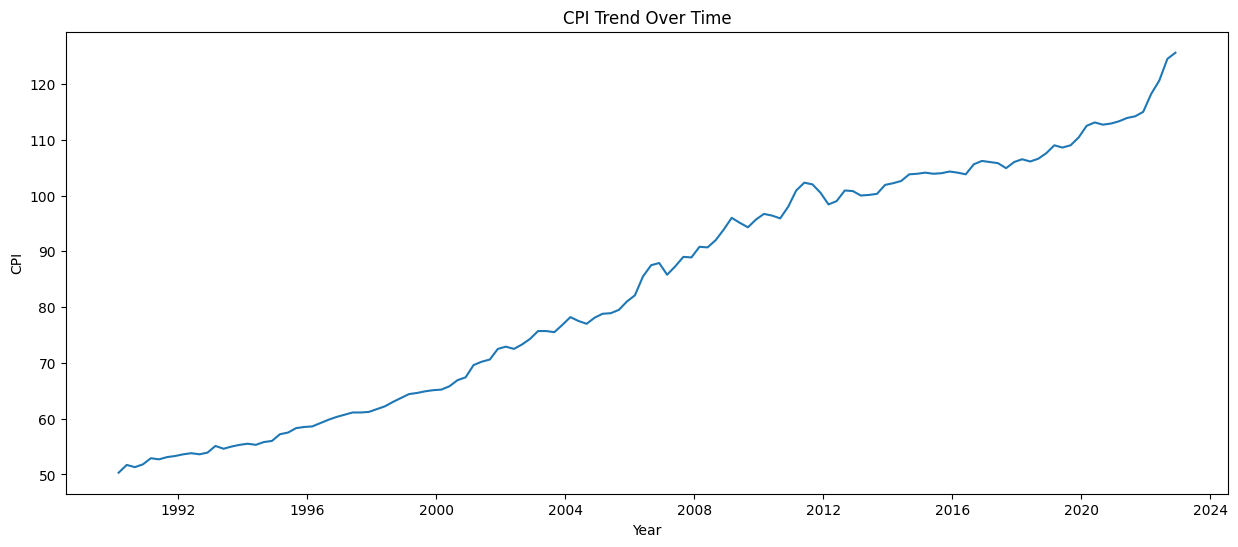

In [ ]:
# Plot the CPI data to observe trends and potential seasonality
plt.figure(figsize=(15, 6))
plt.plot(cpi_train_raw.index,cpi_train)
plt.title('CPI Trend Over Time')
plt.xlabel('Year')
plt.ylabel('CPI')
plt.show()

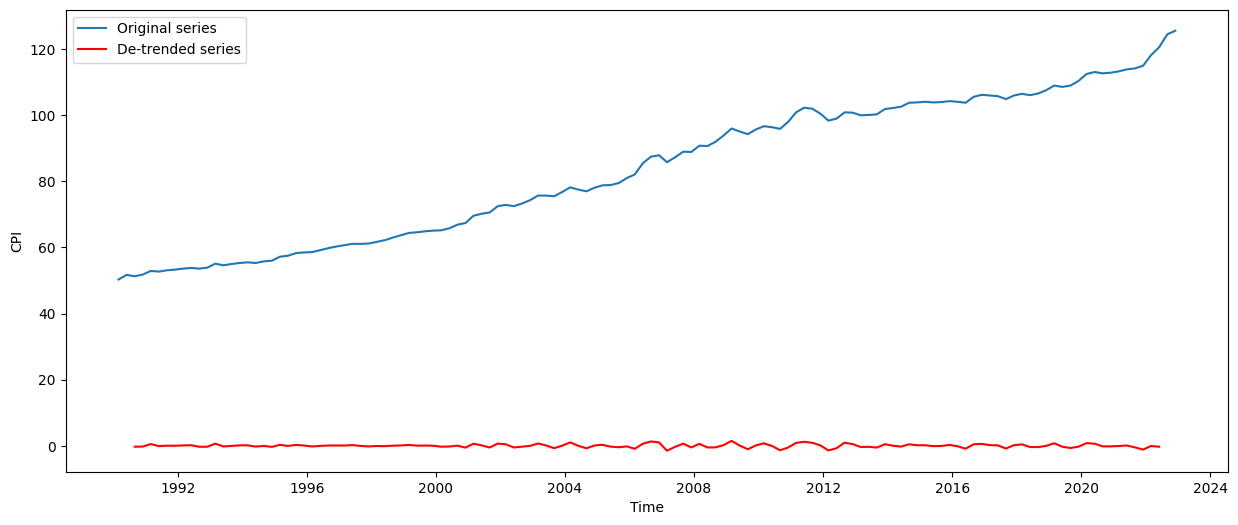

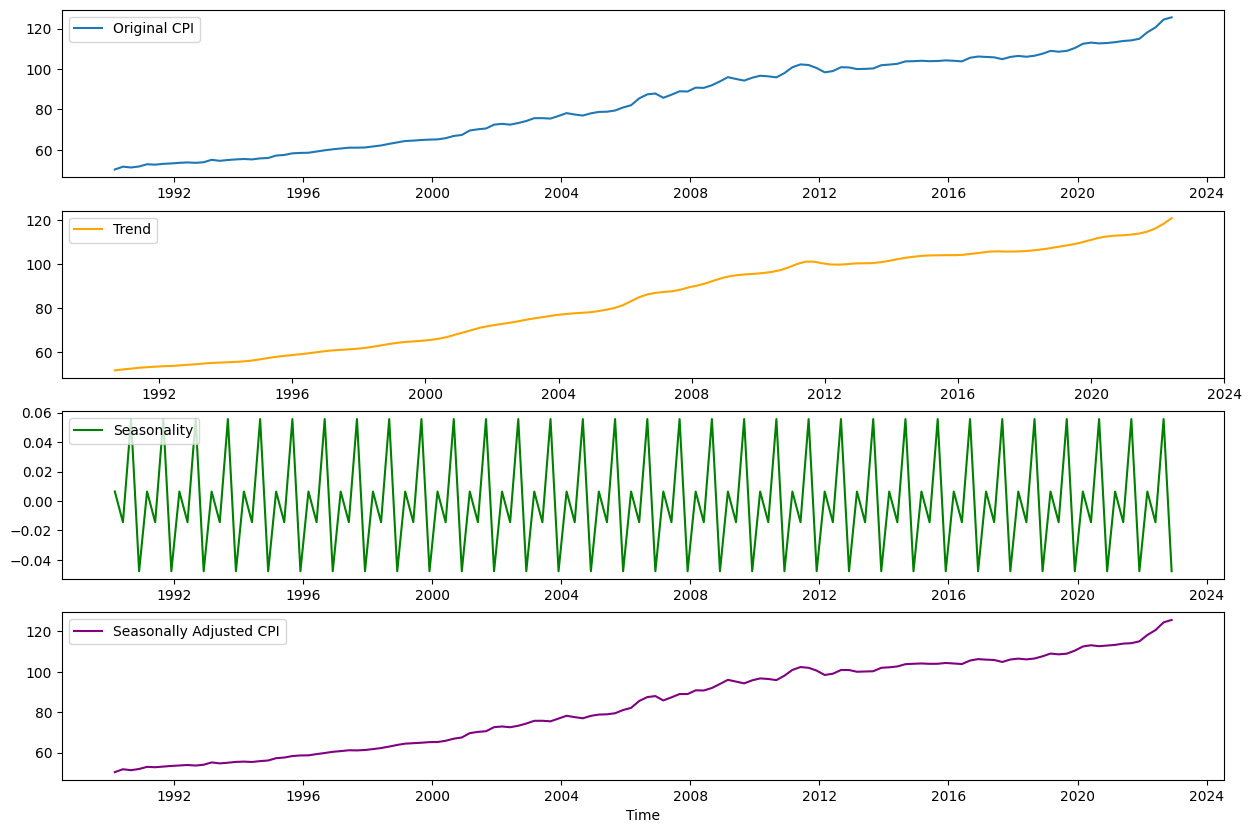

In [ ]:
#Centered Moving Average (CMA) with M=4 to estimate the trend for quarterly data
Trend_init = cpi_train_raw['CPI'].rolling(4, center=True).mean().rolling(2, center=True).mean().shift(-1)

#De-trending by subtracting the estimated trend from the original series
ts_res = cpi_train_raw['CPI'] - Trend_init

# Plot the de-trended and original series
plt.figure(figsize=(15, 6))
plt.plot(cpi_train_raw.index, cpi_train_raw['CPI'], label="Original series")
plt.plot(cpi_train_raw.index, ts_res, 'r-', label="De-trended series")
plt.xlabel('Time')
plt.ylabel('CPI')
plt.legend()
plt.show()

# Replace missing values in the de-trended series with zeros
ts_res_zero = np.nan_to_num(ts_res)

# Reshape the de-trended series for quarterly averages
# Adjust reshaping to match quarterly periods (4 quarters in each year)
try:
    quarterly_S = np.reshape(ts_res_zero, (4, -1))
    # Calculate column averages (average CPI per quarter across all years)
    quarterly_avg = np.mean(quarterly_S, axis=1)
except ValueError:
    print("Reshape error: Ensure series length aligns with quarterly data structure.")

# Calculate and replicate the normalized seasonal index
seasonal_idx_normalized = quarterly_avg - np.mean(quarterly_avg)
seasonal = np.tile(seasonal_idx_normalized, len(cpi_train_raw) // 4)

# Seasonal Adjustment by subtracting the seasonal component from the original series
seasonally_adjusted = cpi_train_raw['CPI'] - seasonal

# Plot the seasonally adjusted data
fig, ax = plt.subplots(4, 1, figsize=(15, 10))
ax[0].plot(cpi_train_raw.index, cpi_train_raw['CPI'], label="Original CPI")
ax[1].plot(cpi_train_raw.index, Trend_init, label="Trend", color="orange")
ax[2].plot(cpi_train_raw.index[:len(seasonal)], seasonal, label="Seasonality", color="green")
ax[3].plot(cpi_train_raw.index, seasonally_adjusted, label="Seasonally Adjusted CPI", color="purple")

ax[0].legend(loc=2)
ax[1].legend(loc=2)
ax[2].legend(loc=2)
ax[3].legend(loc=2)

plt.xlabel('Time')
plt.show()



## 2.2 Stationarity Testing

### 2.2.1 ACF plot

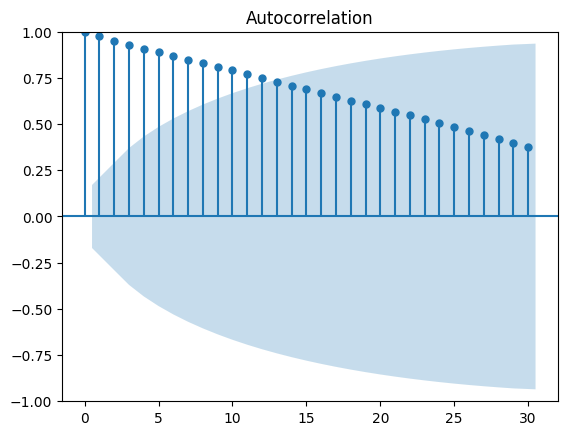

In [ ]:
smt.graphics.tsa.plot_acf(cpi_train, lags=30, alpha = 0.05)
plt.show()

ACF plot: The autocorrelation function (ACF) dies down slowly with increasing lag periods, which usually indicates a trend or non-stationary series.

### 2.2.2 PACF plot

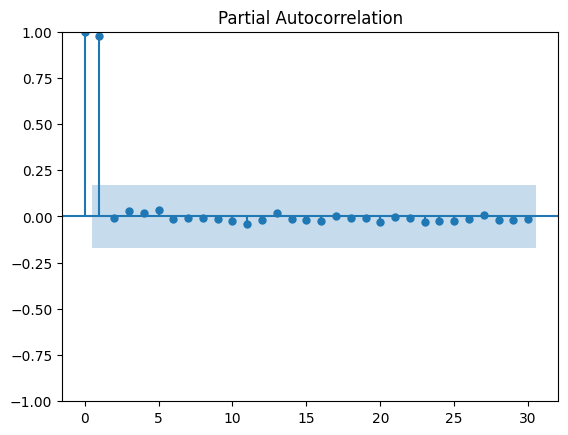

In [ ]:
smt.graphics.tsa.plot_pacf(cpi_train, lags=30, alpha = 0.05)
plt.show()

PACF plot: The partial autocorrelation function (PACF) cuts off rapidly after the initial lag period, which may indicate that the series has a trend component.

The above two plots indicate that the series is not stationary, so the first difference is required.

# 3. Forecasting Models

## 3.1 Holt-Winters Model

In [ ]:
# Train-valid split
validation_size = 8
train_data = cpi_train_raw['CPI'][:-validation_size]
validation_data = cpi_train_raw['CPI'][-validation_size:]

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
# Holt-Winters additive smoothing
fit_add = ExponentialSmoothing(train_data, seasonal_periods=4, trend='add', seasonal='add').fit()
# Holt-Winters multiplicative smoothing
fit_mul = ExponentialSmoothing(train_data, seasonal_periods=4, trend='add', seasonal='mul').fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)


In [ ]:
# symbol r $ and \ in the results variable are the latex symbols for visualization in notebook
results = pd.DataFrame(index=[r"$\alpha$",\
                              r"$\beta$",\
                              r"$\gamma$",\
                              r"$l_0$",\
                              "$b_0$",\
                              "SSE"])
# ExponentialSmoothing() object has following attributes
params = ['smoothing_level', \
          'smoothing_trend', \
          'smoothing_seasonal', \
          'initial_level', \
          'initial_trend']

# check out the performance of additive and multiplicative
results["Additive"]       = [fit_add.params[p] for p in params] + [fit_add.sse]
results["Multiplicative"] = [fit_mul.params[p] for p in params] + [fit_mul.sse]
print(results)

              Additive  Multiplicative
$\alpha$  1.000000e+00    1.000000e+00
$\beta$   8.976447e-10    2.914444e-13
$\gamma$  9.426317e-13    6.340239e-09
$l_0$     4.999731e+01    4.903649e+01
$b_0$     5.102167e-01    5.027492e-01
SSE       9.207312e+01    9.189404e+01


In [ ]:
# Rolling forecast for additive Holt-Winters model
# List to store rolling forecast results
rolling_forecast_add = []
rolling_train_data = train_data.copy()

# Perform rolling forecast, predict 1 step at a time and update training data
for i in range(8):
    # Fit the additive Holt-Winters model with current training data
    fit_add = ExponentialSmoothing(rolling_train_data, seasonal_periods=4, trend='add', seasonal='add').fit()

    next_forecast = fit_add.forecast(steps=1)

    rolling_forecast_add.append(next_forecast[0])

    # Update the training data by adding the actual observation from the validation set
    rolling_train_data = pd.concat([rolling_train_data, validation_data.iloc[[i]]])


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
<ipython-input-13-774ca60f1af9>:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rolling_forecast_add.append(next_forecast[0])
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
<ipython-input-13-774ca60f1af9>:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  

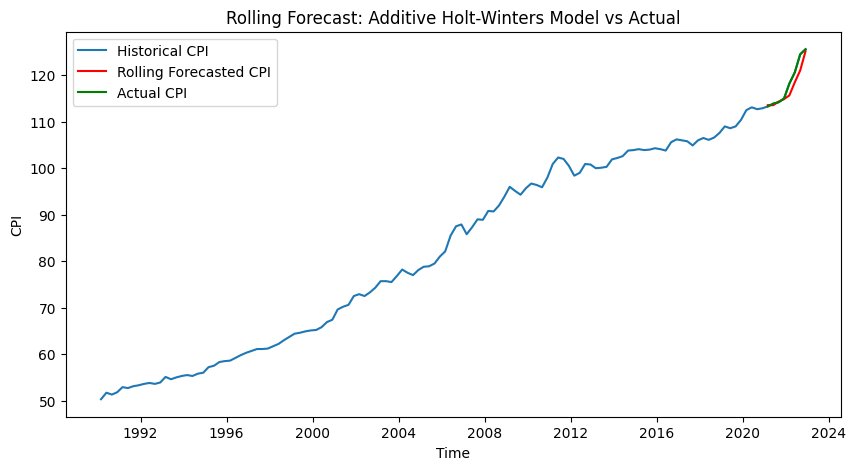

In [ ]:
# Convert rolling forecast results to a pandas Series for plotting
rolling_forecast_series = pd.Series(rolling_forecast_add, index=validation_data.index)

# Plot comparison between rolling forecast, and actual values
plt.figure(figsize=(10, 5))
plt.plot(cpi_train_raw['CPI'], label='Historical CPI')
plt.plot(rolling_forecast_series, label='Rolling Forecasted CPI', color='red')
plt.plot(validation_data[:8], label='Actual CPI', color='green')

plt.xlabel('Time')
plt.ylabel('CPI')
plt.legend()
plt.title('Rolling Forecast: Additive Holt-Winters Model vs Actual')
plt.show()

In [ ]:
# Rolling forecast for multiplicative Holt-Winters model
# List to store rolling forecast results
rolling_forecast_mul = []
rolling_train_data = train_data.copy()

# Perform rolling forecast, predict 1 step at a time and update training data
for i in range(8):
    # Fit the additive Holt-Winters model with current training data
    fit_add = ExponentialSmoothing(rolling_train_data, seasonal_periods=4, trend='add', seasonal='mul').fit()

    next_forecast = fit_add.forecast(steps=1)

    rolling_forecast_mul.append(next_forecast[0])

    # Update the training data by adding the actual observation from the validation set
    rolling_train_data = pd.concat([rolling_train_data, validation_data.iloc[[i]]])


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
<ipython-input-15-cfafcd552c8f>:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rolling_forecast_mul.append(next_forecast[0])
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
<ipython-input-15-cfafcd552c8f>:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  

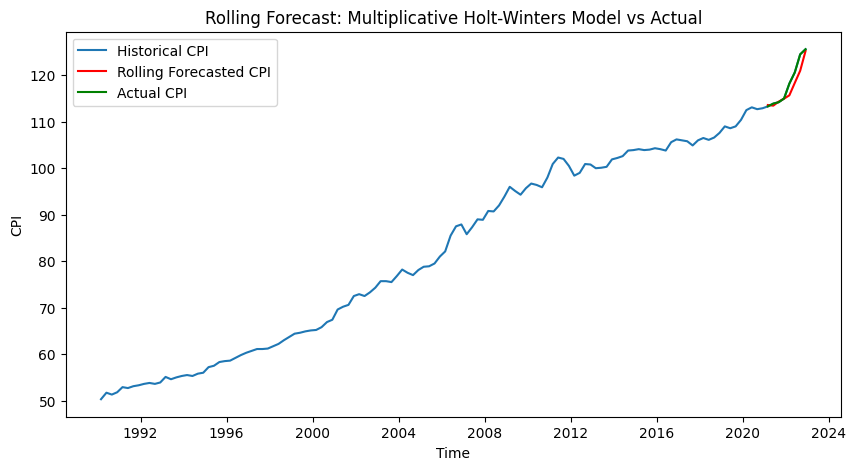

In [ ]:
# Convert rolling forecast results to a pandas Series for plotting
rolling_forecast_series = pd.Series(rolling_forecast_mul, index=validation_data.index)

# Plot comparison between rolling forecast, and actual values
plt.figure(figsize=(10, 5))
plt.plot(cpi_train_raw['CPI'], label='Historical CPI')
plt.plot(rolling_forecast_series, label='Rolling Forecasted CPI', color='red')
plt.plot(validation_data[:8], label='Actual CPI', color='green')

plt.xlabel('Time')
plt.ylabel('CPI')
plt.legend()
plt.title('Rolling Forecast: Multiplicative Holt-Winters Model vs Actual')
plt.show()

In [ ]:
# Calculate the MSE of Additive Holt-Winters Model in the validation set
mse = mean_squared_error(validation_data, rolling_forecast_add)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 2.924997225179121


In [ ]:
# Calculate the MSE of Multiplicative Holt-Winters Model in the validation set
mse = mean_squared_error(validation_data, rolling_forecast_mul)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 3.031809529357751


## 3.2 ARIMA Model

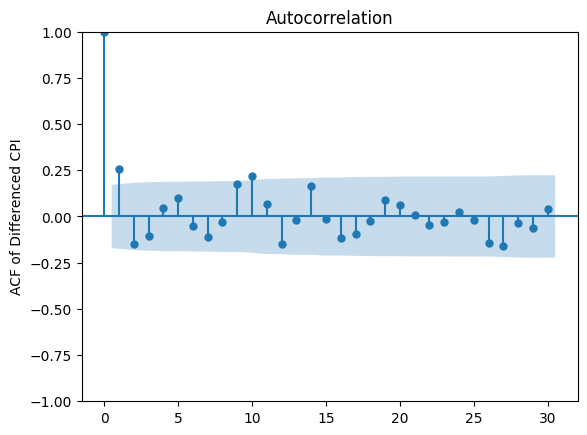

In [ ]:
# Perform differencing on the CPI data to achieve stationarity
cpi_diff = cpi_train_raw['CPI'].diff().dropna()

smt.graphics.tsa.plot_acf(cpi_diff, lags=30, alpha = 0.05)
plt.xlabel('')
plt.ylabel('ACF of Differenced CPI')
plt.show()


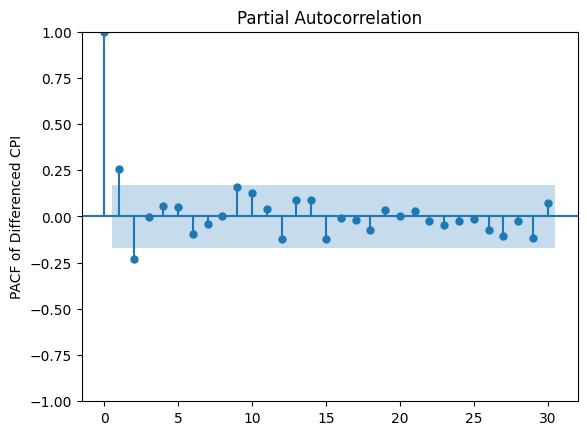

In [ ]:
smt.graphics.tsa.plot_pacf(cpi_diff, lags=30, alpha = 0.05)
plt.xlabel('')
plt.ylabel('PACF of Differenced CPI')
plt.show()

In [ ]:
validation_size = 8
arima_train_data = cpi_train_raw['CPI'][:-validation_size]
arima_validation_data = cpi_train_raw['CPI'][-validation_size:]

In [ ]:
! pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.9 MB/s eta 0:00:00


In [ ]:
import pmdarima as pm

In [ ]:
arima_model = pm.auto_arima(
    arima_train_data,
    start_p=0,              # Starting point for p
    start_q=0,              # Starting point for q
    max_p=5,                # Maximum p value to test
    max_q=5,                # Maximum q value to test
    d=1,                 # Automatically determine d (differencing)
    seasonal=False,         # Set to True for seasonal data (SARIMA)
    stepwise=True,          # Use stepwise search to improve speed
    trace=True,             # Output search progress
    error_action='ignore',  # Ignore convergence warnings
    suppress_warnings=True, # Suppress other warnings
    information_criterion='aic',  # Select the model with the lowest AIC
)

# Summary of the best model
print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=322.216, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=320.420, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=315.997, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=355.556, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=315.037, Time=0.09 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=310.140, Time=0.18 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=308.233, Time=0.15 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=310.124, Time=0.33 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=312.113, Time=1.33 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=338.581, Time=0.11 sec

Best model:  ARIMA(2,1,0)(0,0,0)[0] intercept
Total fit time: 2.700 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  124
Model:               SARIMAX(2, 1, 0)   Log Likelihood                -1

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
# List to store rolling forecast results
arima_predictions = []
arima_actual_values = validation_data.values

# Rolling forecast
for t in range(validation_size):
    # Fit the model with current training data
    arima_model = ARIMA(arima_train_data, order=(2, 1, 0))  #Replace with the optimal parameters
    arima_model_fit = arima_model.fit()

    arima_forecast = arima_model_fit.forecast(steps=1)
    arima_predictions.append(arima_forecast[0])

    # Update the training data by adding the actual observation from the validation set
    arima_train_data = np.append(arima_train_data, arima_actual_values[t])

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
<ipython-input-25-752a65a7d688>:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  arima_predictions.append(arima_forecast[0])


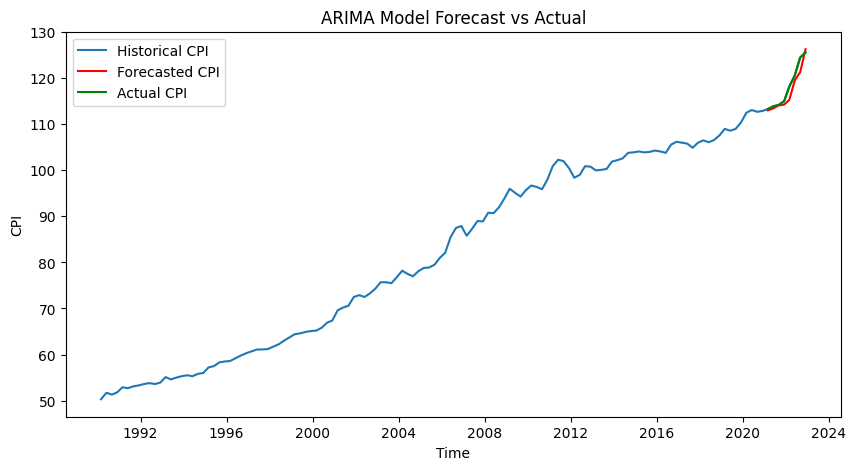

In [ ]:
# Extract the index values for the validation set
validation_index = cpi_train_raw.index[-validation_size:]

# Plot comparison between actual values and forecasted values
plt.figure(figsize=(10, 5))
plt.plot(cpi_train_raw['CPI'], label='Historical CPI')
plt.plot(validation_index, arima_predictions, label='Forecasted CPI', color='red')
plt.plot(validation_index, arima_actual_values, label='Actual CPI', color='green')
plt.xlabel('Time')
plt.ylabel('CPI')
plt.legend()
plt.title('ARIMA Model Forecast vs Actual')
plt.show()

In [ ]:
# Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(arima_actual_values, arima_predictions)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 2.612459696518589


## 3.3 SARIMA Model

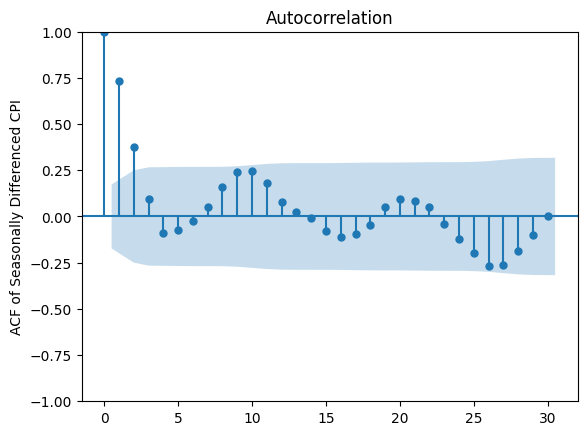

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

seasonal_diff = cpi_train_raw['CPI'].diff(4).dropna()

smt.graphics.tsa.plot_acf(seasonal_diff, lags=30, alpha = 0.05)
plt.xlabel('')
plt.ylabel('ACF of Seasonally Differenced CPI')
plt.show()

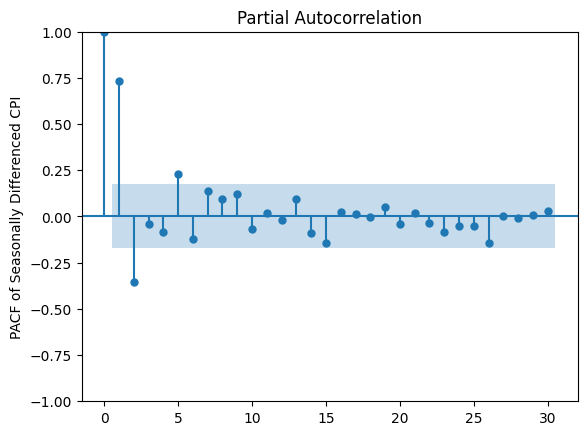

In [ ]:
smt.graphics.tsa.plot_pacf(seasonal_diff, lags=30, alpha = 0.05)
plt.xlabel('')
plt.ylabel('PACF of Seasonally Differenced CPI')
plt.show()

In [ ]:
validation_size = 8
sarima_train_data = cpi_train_raw['CPI'][:-validation_size]
sarima_validation_data = cpi_train_raw['CPI'][-validation_size:]

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA model
sarima_model = SARIMAX(sarima_train_data, order=(2, 1, 0), seasonal_order=(0, 1, 1, 4))
sarima_result = sarima_model.fit()

print(sarima_result.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                                 CPI   No. Observations:                  124
Model:             SARIMAX(2, 1, 0)x(0, 1, [1], 4)   Log Likelihood                -152.127
Date:                             Thu, 31 Oct 2024   AIC                            312.254
Time:                                     02:28:14   BIC                            323.371
Sample:                                 03-01-1990   HQIC                           316.768
                                      - 12-01-2020                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2444      0.072      3.397      0.001       0.103       0.385
ar.L2         -0.3225      

In [ ]:
# List to store rolling forecast results
sarima_predictions = []
sarima_actual_values = sarima_validation_data.values

# Rolling forecast
for t in range(validation_size):
    sarima_model = SARIMAX(sarima_train_data, order=(2, 1, 0), seasonal_order=(0, 1, 1, 4))
    sarima_model_fit = sarima_model.fit(disp=False)

    sarima_forecast = sarima_model_fit.forecast(steps=1)
    sarima_predictions.append(sarima_forecast[0])

    # Update the training data by adding the actual observation from the validation set
    sarima_train_data = np.append(sarima_train_data, sarima_actual_values[t])



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
<ipython-input-32-d5bb608f8dad>:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sarima_predictions.append(sarima_forecast[0])


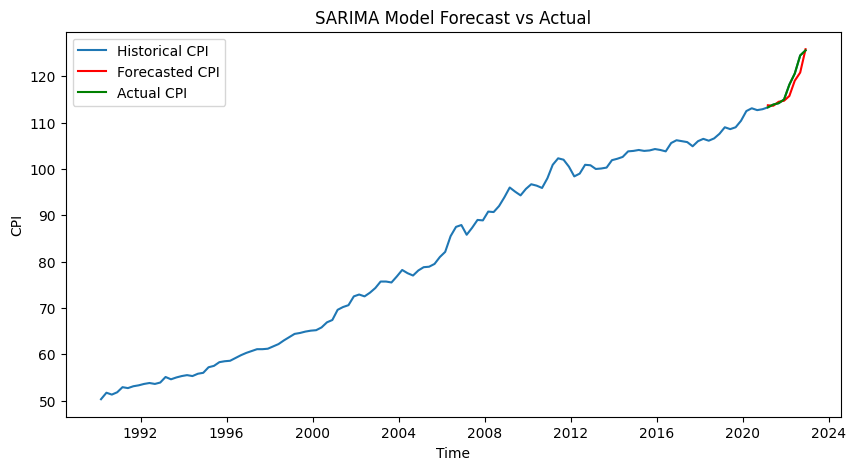

In [ ]:
# Plot comparison between actual values and forecasted values

validation_index = cpi_train_raw.index[-validation_size:]

plt.figure(figsize=(10, 5))
plt.plot(cpi_train_raw['CPI'], label='Historical CPI')
plt.plot(validation_index, sarima_predictions, label='Forecasted CPI', color='red')
plt.plot(validation_index, sarima_actual_values, label='Actual CPI', color='green')
plt.xlabel('Time')
plt.ylabel('CPI')
plt.legend()
plt.title('SARIMA Model Forecast vs Actual')
plt.show()



In [ ]:
# Calculate MSE
mse = mean_squared_error(sarima_actual_values, sarima_predictions)
print(f"Mean Squared Error (MSE) with Rolling Forecast: {mse}")

Mean Squared Error (MSE) with Rolling Forecast: 2.8088681453734434


## 3.4 LSTM Model

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

import random as python_random


In [ ]:
# Set random seeds for reproducibility
np.random.seed(0)
python_random.seed(0)
tf.random.set_seed(0)

# Convert data from DataFrame to array
data_not_scaled = cpi_train_raw['CPI'].dropna().values.astype('float').reshape(-1, 1)

# Define a scaler object
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit and transform using the scaler
data_scaled = scaler.fit_transform(data_not_scaled)

# Define function to create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i - sequence_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Define the grid search parameters
time_window_options = [4, 8, 12]  # Different sequence lengths to try
units_options = [8, 16, 32]       # Different LSTM units to try

# Track the best configuration
best_config = {'time_window': None, 'units': None}
min_val_loss = float("inf")

# Grid search loop
for time_window in time_window_options:
    # Create sequences based on current time_window
    Xall, Yall = create_sequences(data_scaled, time_window)

    # Split into training and validation sets (first 124 train, last 8 dp for validation)
    train_size = len(Xall) - 8  # Ensure at least 8 data points for validation
    Xtrain, Xval = Xall[:train_size], Xall[train_size:]
    Ytrain, Yval = Yall[:train_size], Yall[train_size:]

    # Reshape into 3D array for LSTM
    Xtrain = Xtrain.reshape((Xtrain.shape[0], time_window, 1))
    Xval = Xval.reshape((Xval.shape[0], time_window, 1))

    for units in units_options:
        print(f"Training model with time_window={time_window} and units={units}")

        # Build and compile the model
        model = Sequential()
        model.add(LSTM(units=units, input_shape=(time_window, 1), activation='relu'))
        model.add(Dense(units=1))
        model.compile(optimizer="adam", loss="mean_squared_error")

        # Early stopping to prevent overfitting
        early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1)

        # Train the model
        history = model.fit(Xtrain, Ytrain,
                            epochs=100,      # Use lower epochs for faster testing; increase if necessary
                            batch_size=5,
                            validation_data=(Xval, Yval),
                            shuffle=False,
                            verbose=0,
                            callbacks=[early_stop])

        # Get the validation loss from the last epoch
        val_loss = history.history['val_loss'][-1]
        print(f"Validation Loss for time_window={time_window} and units={units}: {val_loss}")

        # Update the best configuration if current validation loss is lower
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            best_config = {'time_window': time_window, 'units': units}
            best_model = model  # Save the model with best configuration

print(f"\nBest configuration: time_window={best_config['time_window']}, units={best_config['units']} with Validation Loss: {min_val_loss}")


Training model with time_window=4 and units=8


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 23: early stopping
Validation Loss for time_window=4 and units=8: 0.0018796018557623029
Training model with time_window=4 and units=16
Epoch 24: early stopping
Validation Loss for time_window=4 and units=16: 0.0009804628789424896
Training model with time_window=4 and units=32
Epoch 19: early stopping
Validation Loss for time_window=4 and units=32: 0.0025742282159626484
Training model with time_window=8 and units=8
Epoch 20: early stopping
Validation Loss for time_window=8 and units=8: 0.002200123155489564
Training model with time_window=8 and units=16
Epoch 20: early stopping
Validation Loss for time_window=8 and units=16: 0.004343350883573294
Training model with time_window=8 and units=32
Epoch 17: early stopping
Validation Loss for time_window=8 and units=32: 0.0022138541098684072
Training model with time_window=12 and units=8
Epoch 19: early stopping
Validation Loss for time_window=12 and units=8: 0.002317017177119851
Training model with time_window=12 and units=16
Epoch 20: e

In [ ]:
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 16)                  │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,509 (13.71 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,340 (9.14 KB)

# 4. Model Performance Evaluation

## 4.1 LSTM Performance

In [ ]:
# Use the best model for final predictions or further testing
# Create sequences using the best time_window
Xall_best, Yall_best = create_sequences(data_scaled, best_config['time_window'])

# Split into training and validation set
train_size = len(Xall) - 8  # Ensure at least 8 data points for validation
Xtrain_best, Xvali_best = Xall_best[:train_size], Xall_best[train_size:]
Ytrain_best, Yvali_best = Yall_best[:train_size], Yall_best[train_size:]

# Reshape into 3D array for LSTM
Xtrain_best = Xtrain_best.reshape((Xtrain_best.shape[0], best_config['time_window'], 1))
Xvali_best = Xvali_best.reshape((Xvali_best.shape[0], best_config['time_window'], 1))

# Predict using the best model
allPredict = best_model.predict(Xall_best.reshape((Xall_best.shape[0], best_config['time_window'], 1)))

# Transform predictions back to original scale
allPredict_original_scale = scaler.inverse_transform(allPredict)
allPredictPlot = np.empty_like(data_scaled)
allPredictPlot[:, :] = np.nan
allPredictPlot[best_config['time_window']:, :] = allPredict_original_scale

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


In [ ]:
# Calculate Training MSE
# Predict on training data and transform back to original scale
trainPredict = best_model.predict(Xtrain_best)
trainPredict_original_scale = scaler.inverse_transform(trainPredict)
Ytrain_original_scale = scaler.inverse_transform(Ytrain_best.reshape(-1, 1))

train_mse = mean_squared_error(Ytrain_original_scale, trainPredict_original_scale)
print(f'Training Set MSE with best model: {train_mse:.2f}')

# Evaluate model on test data
testPredict = best_model.predict(Xvali_best)
testPredict_original_scale = scaler.inverse_transform(testPredict)
Yvali_original_scale = scaler.inverse_transform(Yvali_best.reshape(-1, 1))

testScore = (mean_squared_error(Yvali_original_scale, testPredict_original_scale))
print(f'Validation Set MSE with best model: {testScore:.2f}')



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Training Set MSE with best model: 1.62
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Validation Set MSE with best model: 3.22


## 4.2 Dynamic Forecast Results


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Dynamic Forecast MSE: 4.15


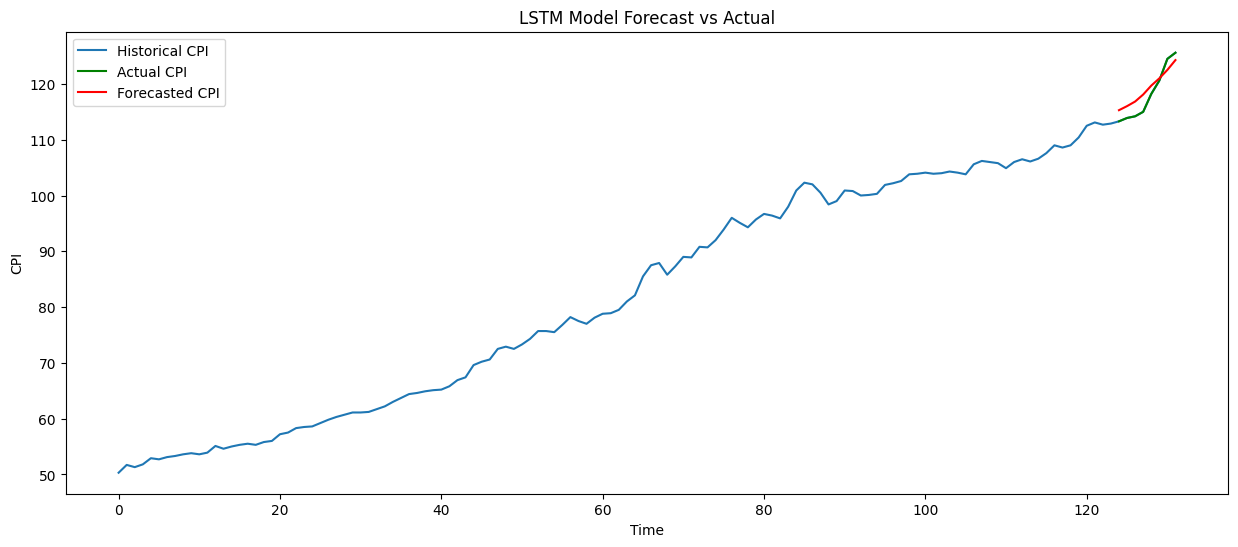

In [ ]:
# dynamic
# Define test_size based on the number of quarters to reserve for testing
test_size = 8

# dynamic prediction
dynamic_prediction = np.copy(data_scaled[:len(data_scaled) - test_size])  # Initial part of scaled data

for i in range(len(data_scaled) - test_size, len(data_scaled)):
    # Get the last 'time_window' values for prediction
    last_sequence = dynamic_prediction[i - best_config['time_window']:i].reshape(1, best_config['time_window'], 1)
    next_pred = best_model.predict(last_sequence)
    dynamic_prediction = np.append(dynamic_prediction, next_pred)  # Append next prediction

# Only keep the dynamic predictions for the test period
dynamic_test_predictions = dynamic_prediction[-test_size:]

# Transform predictions and actual test values back to original scale
dynamic_test_predictions_original_scale = scaler.inverse_transform(dynamic_test_predictions.reshape(-1, 1))
Ytest_original_scale = scaler.inverse_transform(data_scaled[-test_size:].reshape(-1, 1))



# Plotting
test_index = np.arange(len(data_scaled) - test_size, len(data_scaled), 1)

plt.figure(figsize=(15, 6))
plt.plot(scaler.inverse_transform(data_scaled), label='Historical CPI')
plt.plot(test_index, scaler.inverse_transform(data_scaled[-test_size:]), label='Actual CPI', color='green')
plt.plot(test_index, dynamic_test_predictions_original_scale, label='Forecasted CPI', color='red')
plt.legend(loc="upper left")
plt.xlabel('Time')
plt.ylabel('CPI')
plt.title('LSTM Model Forecast vs Actual')

# Compute MSE
dynamic_mse = mean_squared_error(Ytest_original_scale, dynamic_test_predictions_original_scale)
print('Dynamic Forecast MSE: {0:.2f}'.format(dynamic_mse))

# 5. Multi-step Forecast

## 6-Step Ahead CPI Forecast

Finally, we applied the dynamic forecast. In real world, we do not have access to the future values, so we have to do dynamic forecast for multi-step-ahead forecast. This forecast uses observations up to some time point. From that point onwards we append our latest forecast to the list and use a combination of real values and estimated values as input features. Eventually if the forecast length exceeds the window of values used, we will be only using forecast values.

Train the entire training dataset with the best model.

In [ ]:
# Dynamic Forecast
# Train the ARIMA model on the entire training dataset
final_model = ARIMA(cpi_train, order=(2, 1, 0))
final_model_fit = final_model.fit()

# Define the number of steps to forecast
forecast_steps = 6
dynamic_forecast = []

# Initialize the input data with the training data
input_data = cpi_train_raw['CPI']

# Perform dynamic forecasting for each step
for i in range(forecast_steps):
    # Fit the model on the current input data
    model = ARIMA(input_data, order=(2, 1, 0))
    model_fit = model.fit()

    # Forecast the next step
    next_forecast = model_fit.forecast(steps=1)

    # Store the forecasted value
    dynamic_forecast.append(next_forecast[0])

    # Append the forecasted value to the input data for the next prediction
    input_data = pd.concat([input_data, next_forecast])

# Convert the dynamic forecast to a NumPy array
dynamic_forecast = np.array(dynamic_forecast)




/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
<ipython-input-41-f23bb2bd96ac>:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dynamic_forecast.append(next_forecast[0])
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_mo

In [ ]:
# Display dynamic forecast results
print("Dynamic Forecast for 6 steps ahead:")
print(dynamic_forecast)

Dynamic Forecast for 6 steps ahead:
[125.84814244 125.88778209 125.88874633 125.88627832 125.88500131
 125.88456054]


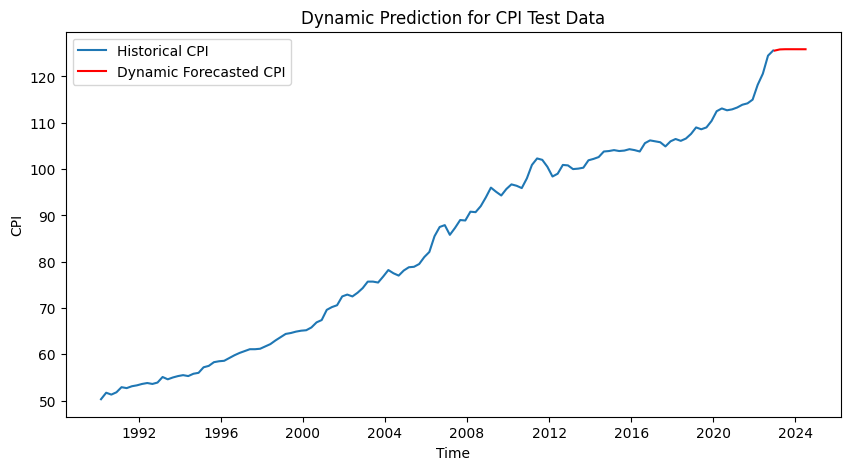

In [ ]:
historical_index = cpi_train_raw.index

dynamic_forecast_with_last_point = np.insert(dynamic_forecast, 0, cpi_train_raw['CPI'].iloc[-1])

dynamic_forecast_index = pd.date_range(start=historical_index[-1], periods=forecast_steps + 1, freq='QE')


plt.figure(figsize=(10, 5))
plt.plot(cpi_train_raw['CPI'], label='Historical CPI')
plt.plot(dynamic_forecast_index, dynamic_forecast_with_last_point, label='Dynamic Forecasted CPI', color='red')
plt.xlabel('Time')
plt.ylabel('CPI')
plt.title('Dynamic Prediction for CPI Test Data')

plt.legend()
plt.show()


# 6. Model Comparison





## Forecast Error (MSE)


In [ ]:
cpi_test = pd.read_csv('CPI_test.csv')

test_error = mean_squared_error(cpi_test['CPI'], dynamic_forecast)
print(test_error)

# 7. Business Insights



*   ARIMA achieved the best performance for CPI forecasting.
*   CPI demonstrates a strong long-term inflation trend.
*   Seasonal effects are relatively minor compared with trend components.




